# Libreria EEGraSP
Biblioteca para el procesamiento del electroencefalograma usando procesamiento de señales sobre grafos. Utiliza NumPy, SciPy, Matplotlib, NetworkX, PyGSP2, y MNE.

- Link al paper: [https://www.scielo.cl/scielo.php?pid=S0718-33052024000100229&script=sci_arttext](https://www.scielo.cl/scielo.php?pid=S0718-33052024000100229&script=sci_arttext)
- Link al repo: [https://github.com/gsp-eeg/EEGraSP](https://github.com/gsp-eeg/EEGraSP)

## Autores
- Alejandro Weinstein (UTFSM)
- Julio Rodiño (UV)
- Camilo Jara (UTFSM)
- Lucas Cortes (Lanek)
- Alejandro Veloz (UV)

## Otras librerias
- PyGSP
- GSPBOX
- GRaSP

> ninguno diseñado para procesar EEG usando GSP

## Carga de Datos y Utilidades

In [1]:
# Cargar los datos acondicionados
from os import path
import pandas as pd

FILE_PATH = './data/eeg_eye_state_clean.csv'

if not path.exists(FILE_PATH):
    print("El archivo no existe.")
    raise FileNotFoundError(f"El archivo no existe: {FILE_PATH}")
else:
    df = pd.read_csv(FILE_PATH)
    print(f"Los datos ya existen en {FILE_PATH}")

Los datos ya existen en ./data/eeg_eye_state_clean.csv


In [2]:
FS = 128  # Frecuencia de muestreo en Hz
CHANNELS = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
TARGET_COL = 'eyeDetection' # 0: ojos abiertos, 1: ojos cerrados
display(df.head())

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection,time_sec
0,0.316986,-0.009590,-0.425512,-0.178237,-0.495224,-0.433845,-0.376640,-0.087048,-0.367611,-0.179262,-0.065064,-0.206539,0.295180,0.311013,0,0.000000
1,0.148499,-0.261122,-0.037817,0.000466,-1.889262,-0.402091,-0.311248,-0.504575,-1.656679,-1.487666,-0.371785,-0.286792,0.059751,-0.097425,0,0.007812
2,0.238762,-0.152250,0.258080,0.429076,-2.289343,-0.829962,-0.285056,-0.936115,-1.394767,-1.577026,-0.374962,0.011411,-0.002536,0.072909,0,0.015625
3,0.364437,0.141366,0.320526,0.498608,-1.509634,-0.950962,-0.305308,-1.127057,-0.857161,-0.378913,-0.068893,0.568022,0.115823,0.538945,0,0.023438
4,0.223377,0.102834,-0.028277,0.257562,-0.775032,-0.465011,-0.394211,-1.558909,-1.450010,0.302976,0.184338,0.703293,0.188884,0.642127,0,0.031250


In [3]:
import mne

# Montaje standard 10/20 con los canales seleccionados (CHANNELS)

montage_name = 'standard_1020'
base_montage = mne.channels.make_standard_montage(montage_name)
ind = [i for (i, channel) in enumerate(base_montage.ch_names) if channel in CHANNELS]
montage = base_montage.copy()
montage.ch_names = [ base_montage.ch_names[i] for i in ind ]
channels_info = [ base_montage.dig[i+3] for i in ind ]
montage.dig = base_montage.dig[0:3]+channels_info

## Creacion de Grafos
$$G = (V, E, W)$$

### Distancia euclidiana
Utiliza un Kernel Gaussiano:
$$W_{ij} = exp(- \frac{d_\epsilon(i, j)^2}{2\sigma^2})$$

Donde:
$$d_{\epsilon}(i, j) = 
\begin{cases} 
d(i, j) & \text{si } d(i, j) \leq \epsilon \\
\infty & \text{si } d(i, j) > \epsilon
\end{cases}$$

- $\sigma$: Factor de dispersión del grafo
- $\epsilon$: Umbral / Limite Superior para las distancias.

### Graph learning
Utiliza el algoritmo de Kalofolias, resolviendo el problema de optimizacion:
$$\min_{W} \sum\limits_{ij} W_{ij} ||x_i - x_j||^2 + a||W||^2_F - b \sum\limits_{i} log( \sum\limits_{j} W_{ij} )$$

Donde:
$$||W||_F = \sum\limits_{i}\sum\limits_{j} |W_{ij}|^2$$

- $||W||_F$: Norma de Frobenius, mide el "tamaño" total de la matriz.
- $a$: Controla la densidad de las conexiones. Un $a$ alto penaliza pesos grandes.
- $b$: Asegura que cada electrodo/canal tenga algunas conexiones. Un $b$ alto obliga a los nodos tener conectividad.

In [4]:
import numpy as np
from eegrasp import EEGrasp

# 1. Extraer coordenadas
eeg_pos_dict = montage.get_positions()['ch_pos']
eeg_pos = np.array([eeg_pos_dict[ch] for ch in CHANNELS])

# ---------------------------------------------------------
# GRAFO 1: Distancia Euclidiana (sigma = 0.1, epsilon = 0.5)
# ---------------------------------------------------------
gsp_1 = EEGrasp(coordinates=eeg_pos, labels=CHANNELS)
Z_euclidean = gsp_1.compute_distance(method='Euclidean')
G1 = gsp_1.compute_graph(epsilon=0.5, sigma=0.1, distances=Z_euclidean)
W1 = gsp_1.graph_weights

# ---------------------------------------------------------
# GRAFO 2: Distancia Euclidiana (sigma = 0.3, epsilon = 0.5)
# ---------------------------------------------------------
gsp_2 = EEGrasp(coordinates=eeg_pos, labels=CHANNELS)
Z_euclidean = gsp_2.compute_distance(method='Euclidean')
G2 = gsp_2.compute_graph(epsilon=0.5, sigma=0.3, distances=Z_euclidean)
W2 = gsp_2.graph_weights

# ---------------------------------------------------------
# GRAFO 3: Graph Learning (Estructura Aprendida)
# ---------------------------------------------------------
# Preparar datos: EEGraSP espera formato (Canales, Tiempo)
eeg_data = df[CHANNELS].values.T

gsp_3 = EEGrasp(coordinates=eeg_pos, labels=CHANNELS)
gsp_3.data = eeg_data

# Aprender la estructura (Kalofolias).
W3, Z3_learned = gsp_3.learn_graph(a=0.34, b=0.4)
G3 = gsp_3.compute_graph(W3)

# Pequeño print para confirmar que todo se ejecutó bien
print("\nGrafos construidos en memoria:")
print(f" - Grafo 1 (Físico sigma=0.1): W={W1.shape}")
print(f" - Grafo 2 (Físico sigma=0.3): W={W2.shape}")
print(f" - Grafo 3 (Funcional/Aprendido): W={W3.shape}")

Found solution after 238 iterations
Found solution after 238 iterations

Grafos construidos en memoria:
 - Grafo 1 (Físico sigma=0.1): W=(14, 14)
 - Grafo 2 (Físico sigma=0.3): W=(14, 14)
 - Grafo 3 (Funcional/Aprendido): W=(14, 14)


## Visualizar Grafos

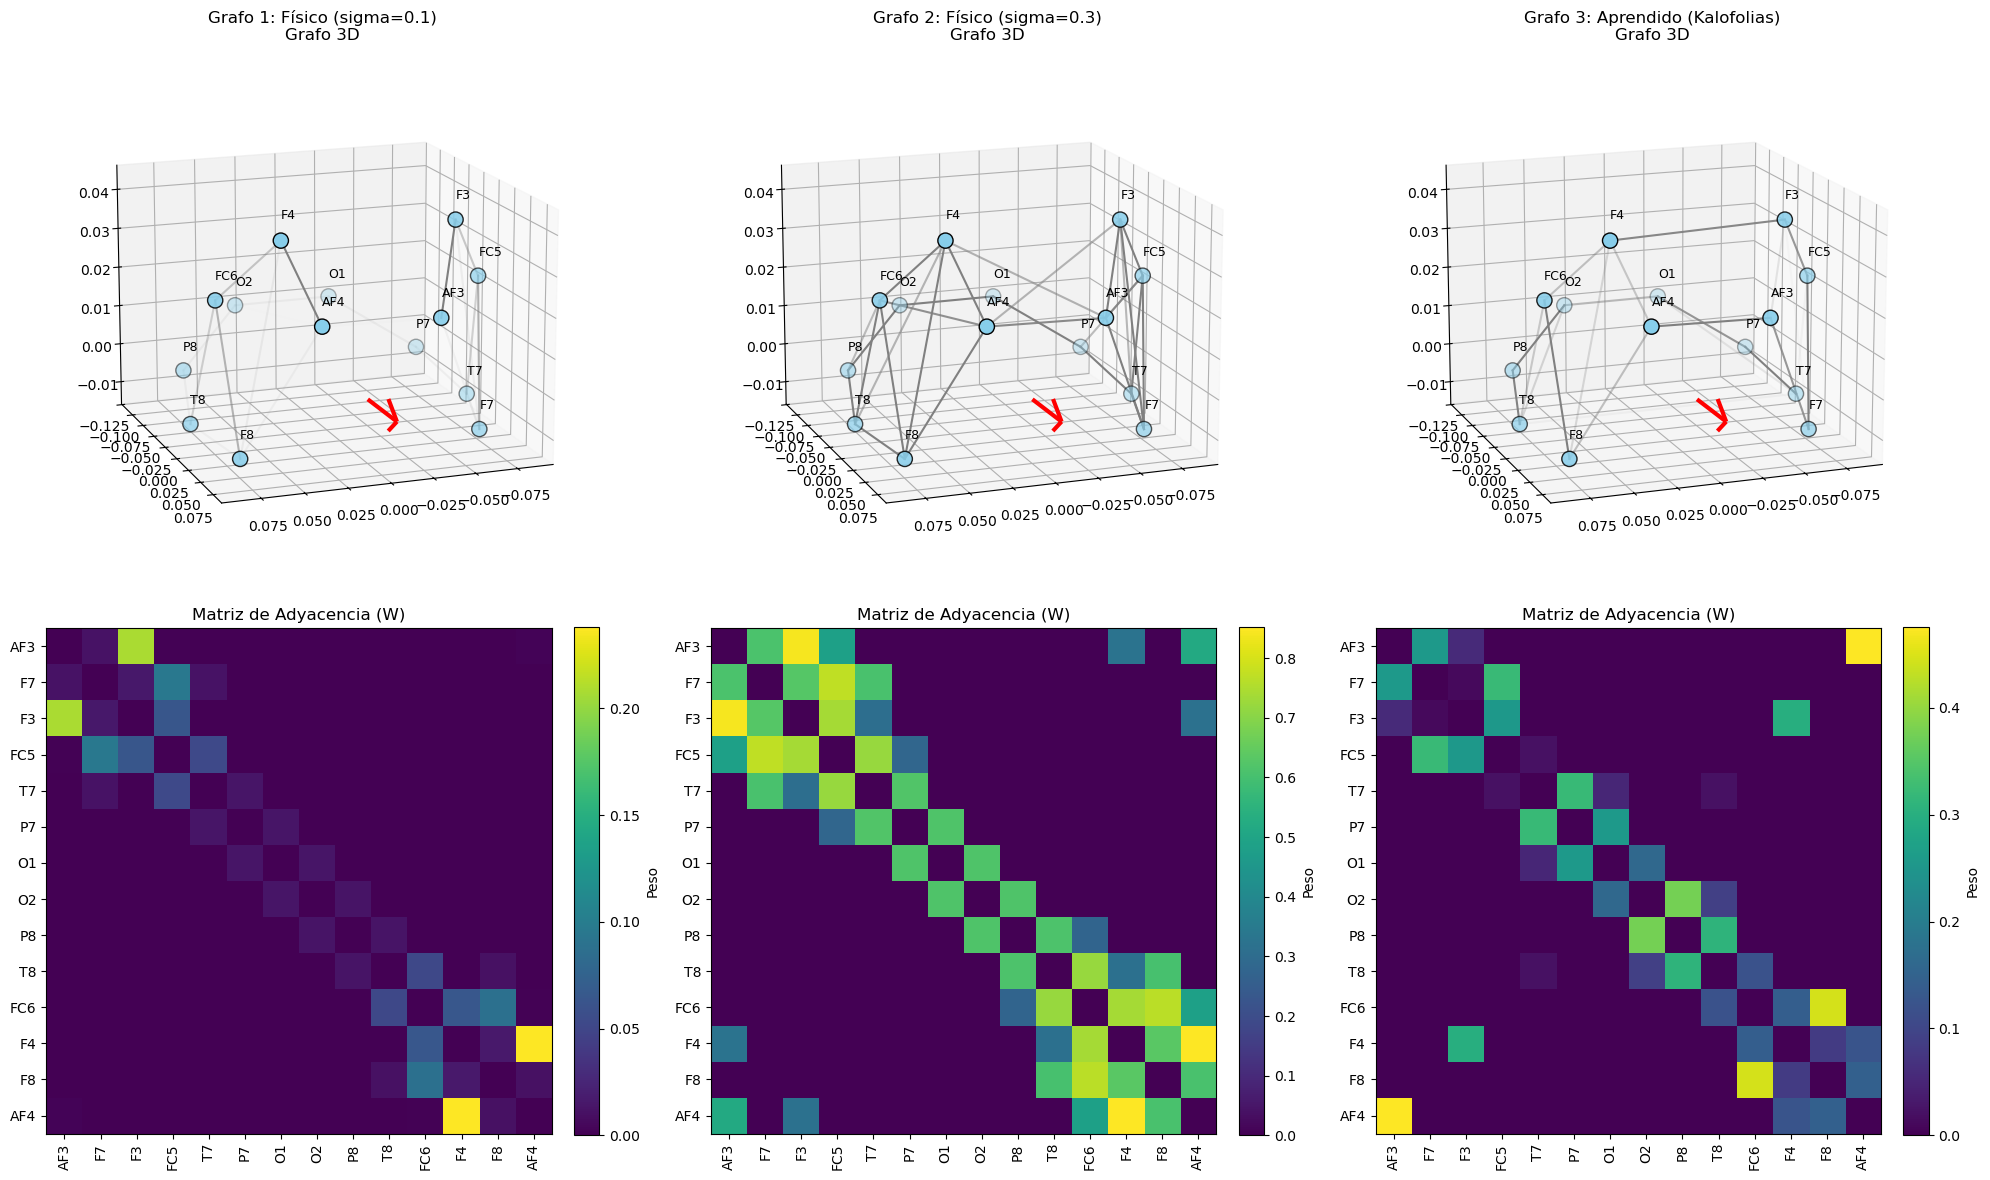

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Creamos una figura más ancha para acomodar 2 filas y 3 columnas (horizontal)
fig = plt.figure(figsize=(20, 12))

def plot_graph_components(ax_3d, ax_mat, W, title, pos, labels):
    """Función auxiliar para dibujar el grafo 3D y la matriz en sus respectivos ejes."""
    
    # Convertir a array denso si es necesario
    W_array = W.toarray() if hasattr(W, 'toarray') else W
    
    # --- 1. DIBUJAR GRAFO 3D ---
    # Nodos
    ax_3d.scatter(pos[:, 0], pos[:, 1], pos[:, 2], 
                  color='skyblue', s=120, edgecolors='black', zorder=5)
    
    # Etiquetas y Nariz
    for i, txt in enumerate(labels):
        ax_3d.text(pos[i, 0], pos[i, 1], pos[i, 2] + 0.005, txt, size=9, zorder=10)
    ax_3d.quiver(0, 0.05, 0, 0, 0.05, 0, color='red', lw=3, arrow_length_ratio=0.3, zorder=1)
    
    # Aristas con transparencia dinámica
    sources, targets = np.where(W_array > 0)
    # Buscamos el peso máximo para normalizar el alpha visualmente
    max_w = np.max(W_array) if np.max(W_array) > 0 else 1.0 
    
    for s, t in zip(sources, targets):
        if s < t:
            peso = W_array[s, t]
            # Normalizamos el peso respecto al máximo del grafo actual para que 
            # las conexiones principales siempre se vean bien, sin importar la escala.
            alpha_val = min((peso / max_w) * 1.5, 1.0) 
            
            ax_3d.plot([pos[s, 0], pos[t, 0]], 
                       [pos[s, 1], pos[t, 1]], 
                       [pos[s, 2], pos[t, 2]], 
                       color='gray', alpha=alpha_val, lw=1.5, zorder=0)

    ax_3d.view_init(azim=70, elev=15)
    ax_3d.set_title(f'{title}\nGrafo 3D', pad=10)

    # --- 2. DIBUJAR MATRIZ DE PESOS ---
    im = ax_mat.imshow(W_array, cmap='viridis')
    ax_mat.set_title(f'Matriz de Adyacencia (W)')
    plt.colorbar(im, ax=ax_mat, fraction=0.046, pad=0.04, label='Peso')
    
    # Ponemos los nombres de los canales en los ejes para mayor claridad
    ax_mat.set_xticks(range(len(labels)))
    ax_mat.set_xticklabels(labels, rotation=90)
    ax_mat.set_yticks(range(len(labels)))
    ax_mat.set_yticklabels(labels)


# ==========================================
# CONSTRUCCIÓN DE LA CUADRÍCULA (2 FILAS x 3 COLUMNAS)
# ==========================================

# Columna 1: Grafo 1 (sigma=0.1)
# 1 = Arriba Izquierda | 4 = Abajo Izquierda
ax1_3d = fig.add_subplot(2, 3, 1, projection='3d')
ax1_mat = fig.add_subplot(2, 3, 4)
plot_graph_components(ax1_3d, ax1_mat, W1, "Grafo 1: Físico (sigma=0.1)", eeg_pos, CHANNELS)

# Columna 2: Grafo 2 (sigma=0.3)
# 2 = Arriba Centro | 5 = Abajo Centro
ax2_3d = fig.add_subplot(2, 3, 2, projection='3d')
ax2_mat = fig.add_subplot(2, 3, 5)
plot_graph_components(ax2_3d, ax2_mat, W2, "Grafo 2: Físico (sigma=0.3)", eeg_pos, CHANNELS)

# Columna 3: Grafo 3 (Aprendido)
# 3 = Arriba Derecha | 6 = Abajo Derecha
ax3_3d = fig.add_subplot(2, 3, 3, projection='3d')
ax3_mat = fig.add_subplot(2, 3, 6)
plot_graph_components(ax3_3d, ax3_mat, W3, "Grafo 3: Aprendido (Kalofolias)", eeg_pos, CHANNELS)

plt.tight_layout()
plt.show()

## Otras Utilidades de Visualizacion
### Laplaciano Combinatorial $L_{n\times n}$
$$L = D - W$$
- $D$: Matriz de Grado
- $W$: Matriz de Pesos

### Autovalores $\lambda_k$
$$Lu = \lambda u$$
- $\lambda$: Frecuencias Espaciales (Directamente proporcional a la frecuencia)
- $\lambda_0 = 0$: Componente continua / Señal constante 

### Autovectores $u_k$
$$Lu = \lambda u$$

- $u$: Bases / Patrones Oscilatorios Espaciales (Mas complejo a medida que aumenta $\lambda$)

### Grafo Aprendido vs Grafo Euclidiano
- Grafo Euclidiano → $A$ esta cerca de $B$
- Grafo Aprendido → $A$ esta conectado con $B$ (segun activacion de las señales)

/home/madmti/anaconda3/lib/python3.13/site-packages/pygsp2/plotting.py:589: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  sc = ax.scatter(*G.coords.T,


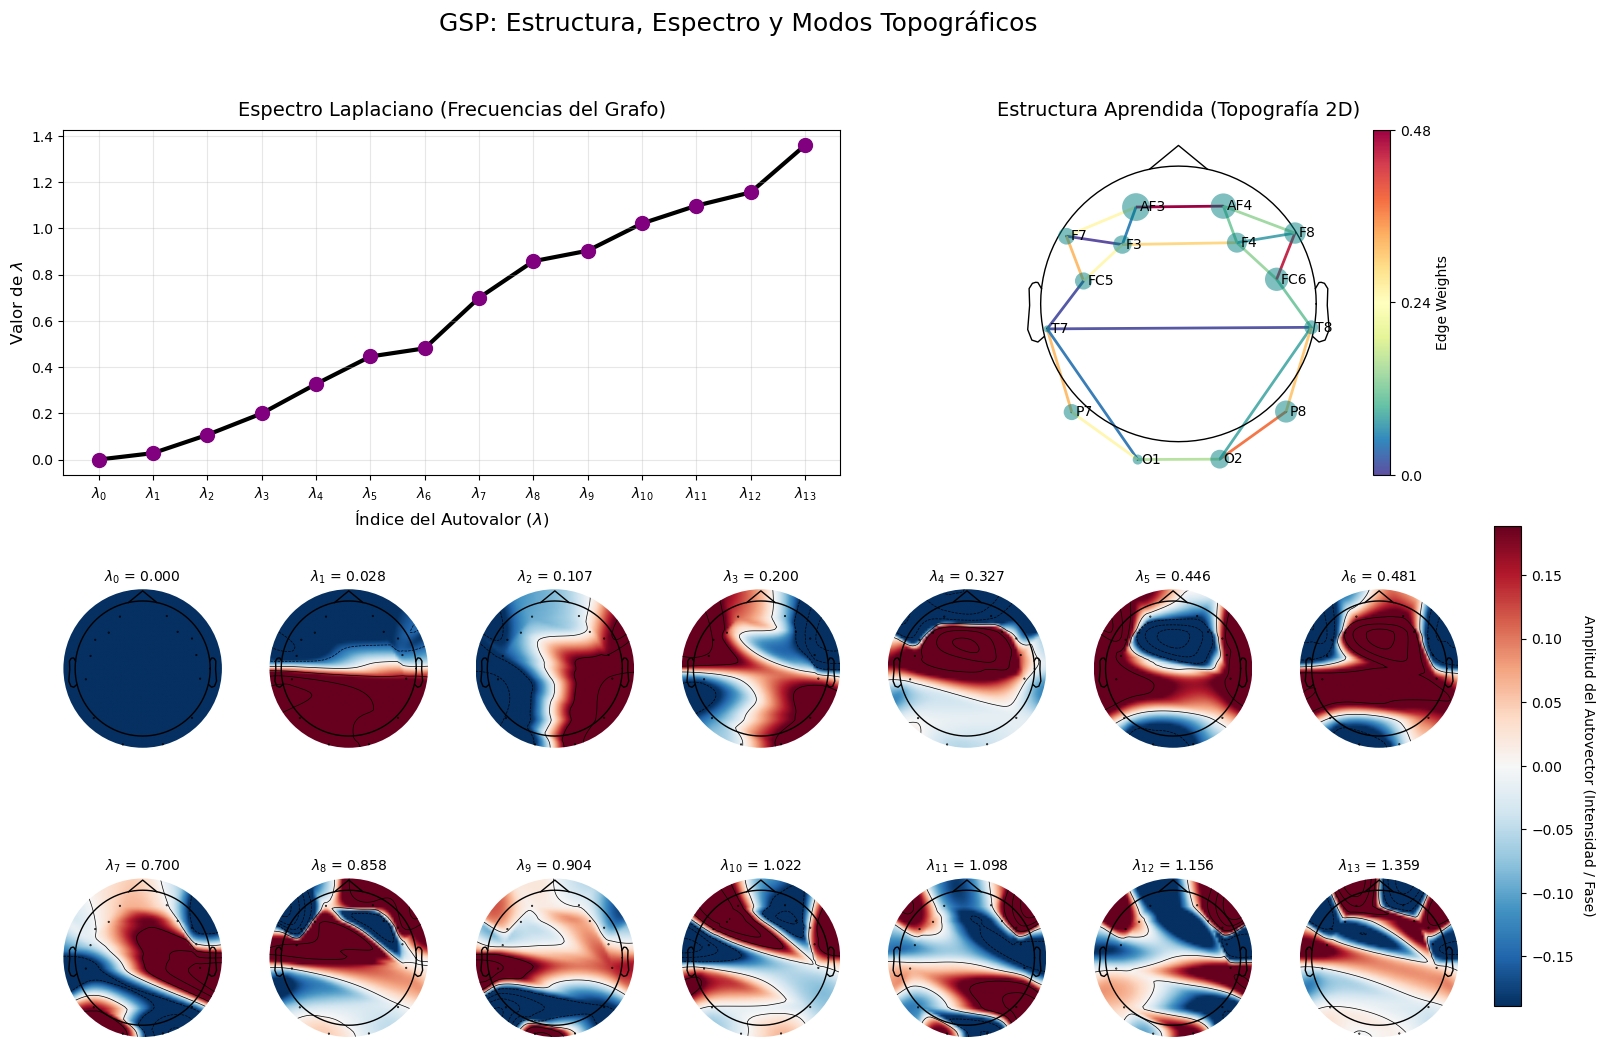

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from eegrasp.viz import plot_graph
import mne

# 1. Preparar datos
pos_2d = eeg_pos[:, :2] # Extraemos solo X e Y para la topografía
W3_array = W3.toarray() if hasattr(W3, 'toarray') else W3

# 2. Calcular el Laplaciano y la Base de Fourier (Grafo Aprendido G3)
G3.set_coordinates(eeg_pos)
G3.compute_laplacian()
G3.compute_fourier_basis()

evals = np.array(G3.e)
U = np.array(G3.U)

# 3. Configurar la Figura Master usando GridSpec
fig = plt.figure(figsize=(18, 12)) # Figura ancha para acomodar todo
gs = gridspec.GridSpec(3, 7, height_ratios=[1.8, 1, 1], hspace=0.4, wspace=0.3)

# =========================================================
# PARTE SUPERIOR IZQUIERDA: ESPECTRO LAPLACIANO (Cols 0 a 3)
# =========================================================
ax_spec = fig.add_subplot(gs[0, 0:4])
ax_spec.plot(np.arange(len(evals)), evals, linewidth=3, color='black', zorder=1)
ax_spec.scatter(np.arange(len(evals)), evals, s=100, color='purple', zorder=2)

ax_spec.set_title('Espectro Laplaciano (Frecuencias del Grafo)', fontsize=14, pad=10)
ax_spec.set_xlabel('Índice del Autovalor ($\lambda$)', fontsize=12)
ax_spec.set_ylabel('Valor de $\lambda$', fontsize=12)
ax_spec.grid(alpha=0.3)
ax_spec.set_xticks(np.arange(len(evals)))
ax_spec.set_xticklabels([f'$\lambda_{{{i}}}$' for i in range(len(evals))])

# =========================================================
# PARTE SUPERIOR DERECHA: GRAFO 2D (Cols 4 a 6)
# =========================================================
ax_graph = fig.add_subplot(gs[0, 4:7])

plot_graph(eegrasp=gsp_3, axis=ax_graph)

ax_graph.set_title('Estructura Aprendida (Topografía 2D)', fontsize=14, pad=10)

# =========================================================
# PARTE INFERIOR: LOS 14 EIGENMODES (TOPOMAPS DE MNE)
# =========================================================
# Escalar los colores para que el 0 (blanco) quede siempre en el centro
SCALE = 0.25
vlim = (-np.amax(np.abs(U)) * SCALE, np.amax(np.abs(U)) * SCALE)

for i in range(len(evals)):
    # Calcular fila (1 o 2) y columna (0 a 6)
    row = 1 + (i // 7)  
    col = i % 7         
    
    ax_topo = fig.add_subplot(gs[row, col])
    
    # Usar MNE para dibujar el mapa de calor interpolado
    im, _ = mne.viz.plot_topomap(U[:, i], pos_2d, sensors=True, axes=ax_topo,
                                 cmap='RdBu_r', vlim=vlim, show=False, sphere=0.1)
    
    ax_topo.set_title(f'$\lambda_{{{i}}}$ = {evals[i]:.3f}', fontsize=10)

# =========================================================
# DETALLES FINALES
# =========================================================
# Barra de color global a la derecha
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.4])  
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Amplitud del Autovector (Intensidad / Fase)', rotation=270, labelpad=15)
fig.suptitle('GSP: Estructura, Espectro y Modos Topográficos', fontsize=18, y=0.98)

plt.show()

## Reconstruccion/Interpolacion de Señal
La reconstruccion se basa en que asumimos que la señal varia suavemente sobre el grafo. Entonces el valor del electrodo/canal faltante deberia ser aproximadamente el promedio ponderado de sus vecinos:
$$\min_{\hat{x}_i} ||\hat{x} - x_{conocido}||^2 + \gamma \hat{x}^T L \hat{x}$$

- $x_{conocido}$: Señal conocida.
- $\hat{x}$: Señal estimada.

### `fit_sigma`
#### Conociendo la señal original
Busca el mejor valor de $\sigma$ para el cual existe el menor valor de MSE entre la señal reconstruida y la original.

#### Sin la señal original
Se puede entrenar un $\sigma$ para un vecino muy relacionado a la señal perdida.

Optimizando Grafo Euclidiano...


100%|██████████| 25/25 [00:01<00:00, 13.48it/s]


Aprendiendo estructura funcional y optimizando...
Found solution after 236 iterations
Found solution after 236 iterations


100%|██████████| 25/25 [00:01<00:00, 13.35it/s]


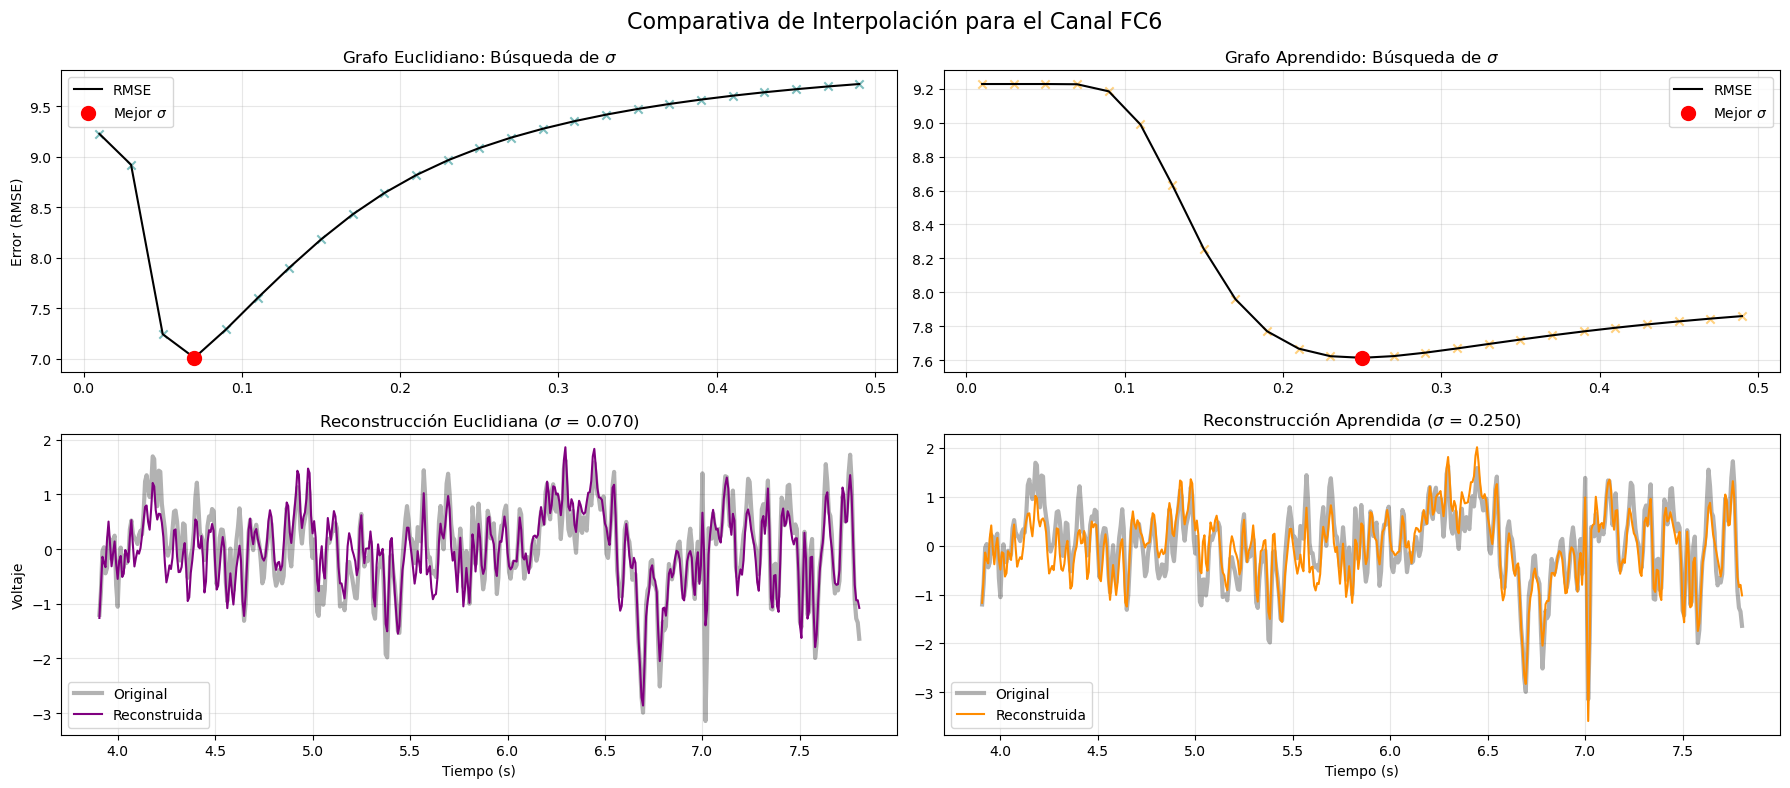

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from eegrasp import EEGrasp

# 1. Configuración de la prueba
canal_a_borrar = 'FC6' # Probar tambien 'AF4'
MISSING_IDX = CHANNELS.index(canal_a_borrar)

start_idx, end_idx = 500, 1000
data_window = df[CHANNELS].iloc[start_idx:end_idx].values.T
time_axis = df['time_sec'].iloc[start_idx:end_idx] if 'time_sec' in df.columns else np.arange(data_window.shape[1])

# Inicializar instancia principal
eegsp_interp = EEGrasp(data=data_window, coordinates=eeg_pos, labels=CHANNELS)

# ==========================================
# PROCESO A: Grafo Euclidiano (Físico)
# ==========================================
print("Optimizando Grafo Euclidiano...")
dist_euclid = eegsp_interp.compute_distance(method='Euclidean', normalize=True)

res_euclid = eegsp_interp.fit_sigma(
    missing_idx=MISSING_IDX, 
    distances=dist_euclid, 
    epsilon=0.5,
    min_sigma=0.01, max_sigma=0.5, step=0.02
)

# ==========================================
# PROCESO B: Grafo Aprendido (Funcional)
# ==========================================
print("Aprendiendo estructura funcional y optimizando...")
# Usamos los parámetros a y b de tu ejemplo anterior para aprender la estructura
W_learn, dist_learn = eegsp_interp.learn_graph(a=0.34, b=0.4)

# Normalizamos las distancias aprendidas para mantener la coherencia con epsilon=0.5
dist_learn_norm = (dist_learn - np.min(dist_learn)) / (np.max(dist_learn) - np.min(dist_learn))

res_learn = eegsp_interp.fit_sigma(
    missing_idx=MISSING_IDX, 
    distances=dist_learn_norm, 
    epsilon=0.5,
    min_sigma=0.01, max_sigma=0.5, step=0.02
)

# ==========================================
# VISUALIZACIÓN LADO A LADO
# ==========================================
# Creamos una figura más ancha (ej. 18x8) con 2 filas y 2 columnas
fig, axs = plt.subplots(2, 2, figsize=(18, 8))

# --- COLUMNA 1: GRAFO EUCLIDIANO ---
# Panel Superior Izquierdo: Curva de Error Euclidiano
axs[0, 0].plot(res_euclid['sigma'], res_euclid['error'], color='black', label='RMSE')
axs[0, 0].scatter(res_euclid['sigma'], res_euclid['error'], color='teal', marker='x', alpha=0.5)
axs[0, 0].scatter(res_euclid['best_sigma'], res_euclid['error'][res_euclid['sigma'] == res_euclid['best_sigma']], color='red', s=100, label='Mejor $\sigma$', zorder=5)
axs[0, 0].set_title(f'Grafo Euclidiano: Búsqueda de $\sigma$')
axs[0, 0].set_ylabel('Error (RMSE)')
axs[0, 0].legend()
axs[0, 0].grid(alpha=0.3)

# Panel Inferior Izquierdo: Reconstrucción Euclidiana
axs[1, 0].plot(time_axis, data_window[MISSING_IDX, :], label='Original', color='black', alpha=0.3, lw=3)
axs[1, 0].plot(time_axis, res_euclid['signal'][MISSING_IDX, :], label='Reconstruida', color='purple')
axs[1, 0].set_title(f'Reconstrucción Euclidiana ($\sigma$ = {res_euclid["best_sigma"]:.3f})')
axs[1, 0].set_xlabel('Tiempo (s)')
axs[1, 0].set_ylabel('Voltaje')
axs[1, 0].legend()
axs[1, 0].grid(alpha=0.3)

# --- COLUMNA 2: GRAFO APRENDIDO ---
# Panel Superior Derecho: Curva de Error Aprendido
axs[0, 1].plot(res_learn['sigma'], res_learn['error'], color='black', label='RMSE')
axs[0, 1].scatter(res_learn['sigma'], res_learn['error'], color='orange', marker='x', alpha=0.5)
axs[0, 1].scatter(res_learn['best_sigma'], res_learn['error'][res_learn['sigma'] == res_learn['best_sigma']], color='red', s=100, label='Mejor $\sigma$', zorder=5)
axs[0, 1].set_title(f'Grafo Aprendido: Búsqueda de $\sigma$')
axs[0, 1].legend()
axs[0, 1].grid(alpha=0.3)

# Panel Inferior Derecho: Reconstrucción Aprendida
axs[1, 1].plot(time_axis, data_window[MISSING_IDX, :], label='Original', color='black', alpha=0.3, lw=3)
axs[1, 1].plot(time_axis, res_learn['signal'][MISSING_IDX, :], label='Reconstruida', color='darkorange')
axs[1, 1].set_title(f'Reconstrucción Aprendida ($\sigma$ = {res_learn["best_sigma"]:.3f})')
axs[1, 1].set_xlabel('Tiempo (s)')
axs[1, 1].legend()
axs[1, 1].grid(alpha=0.3)

# Ajustes finales para que no se superpongan los textos
plt.suptitle(f'Comparativa de Interpolación para el Canal {canal_a_borrar}', fontsize=16)
plt.tight_layout()
plt.show()